# Cover Letter Agent - V2, written paragraph by paragraph

Three paragraphs are drafted independently and in parallel, then reconciled into one letter by a
single review pass at the end.

```
                     ┌─> prepare ─┬─> qualify ──> para_body ────┐
START ─> load ───────┤            └─> para_close ───────────────┼─> assemble ─> END
                     └─> research ──> para_intro ────────────────┘
```

- `prepare` redacts employers and pulls closing paragraphs from your past letters.
- `research` finds facts about the company/team, each tied to a source URL, plus reasons a
  candidate might want the role.
- `para_intro`, `qualify` → `para_body`, and `para_close` each depend only on their own upstream
  branch - none of them see one another's output - so all three run concurrently.
- `assemble` stitches the three paragraphs, runs deterministic checks (length, redacted names,
  placeholders, salutation, sign-off), then a single LLM pass fixes everything found plus any
  duplication or disjointedness left over from writing the paragraphs blind to each other.

## Why it is shaped this way

**Each node emits a human-legible artifact.** When paragraph two is weak you know which node to
fix. That is not true of designs whose intermediate products are evidence maps and briefs.

**`qualify` asks the question most cover letters get wrong.** Not "which of my qualifications are
relevant" but *how each one would add value to this team*. A letter saying "I have X" is weaker
than one saying "X solves Y for you", and this is the node that forces the second form.

**Paragraphs are written blind to each other, on purpose, for latency.** `research` is the slow
step (multiple web searches); running `qualify`/`para_body` and `para_close` concurrently with it
hides their latency instead of adding to it. The trade-off - paragraphs that might repeat a hook
or read disjointedly - is caught by `assemble`'s review pass instead of prevented by sequencing.

**One review pass at the end, not a fact-check loop.** `assemble` no longer checks claims against
the CV; it only reconciles the three independently-written paragraphs into one coherent letter.
The V1 experiment showed two gates arguing with each other - a quality reviewer demanding stronger
claims while a fact checker rejected them - so this stays a single pass, not a loop.

---
## 1. Setup

```bash
uv venv --python 3.13
uv pip install langgraph langchain-anthropic python-dotenv ipykernel pypdf python-docx
```

`.env` next to this notebook:

```
ANTHROPIC_API_KEY=sk-ant-...
```

In [1]:
import os
from dotenv import find_dotenv, load_dotenv

# must run before the langchain/langgraph imports below: langsmith caches whether tracing is
# enabled the first time anything reads the env var, so importing those packages first makes
# LANGSMITH_TRACING silently no-op even once .env is loaded
load_dotenv(find_dotenv(usecwd=True))

import html
import inspect
import json
import re
from dataclasses import dataclass, asdict
from datetime import date
from pathlib import Path
from typing import Optional, TypedDict

from IPython.display import Markdown, display
from pydantic import BaseModel, Field

from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import END, START, StateGraph

assert os.environ.get("ANTHROPIC_API_KEY"), "Put ANTHROPIC_API_KEY in a .env file next to this notebook"
print("Anthropic key loaded.")


Anthropic key loaded.


---
## 2. Configuration

The word budgets are per paragraph rather than for the letter as a whole. Three writers each
asked for "a paragraph" reliably sprawl; given a number, they do not.

In [2]:
@dataclass
class Config:
    model: str = "claude-opus-5"
    output_language: str = "English"

    # per-section word budgets
    intro_words: int = 90
    body_words: int = 190
    close_words: int = 45
    max_words: int = 400        # hard ceiling for the assembled letter

    # employers NOT listed here are replaced by generic descriptors before anything is written
    nameable_employers: tuple = ("ASML", "Philips")
    redact_employers: bool = True

    web_search_max_uses: int = 6
    dump_prompts: bool = True   # write every rendered prompt to outputs/.prompts/

    inputs_dir: Path = Path("inputs")
    outputs_dir: Path = Path("outputs")


cfg = Config()
cfg.outputs_dir.mkdir(parents=True, exist_ok=True)
print(json.dumps({k: str(v) for k, v in asdict(cfg).items()}, indent=2))


{
  "model": "claude-opus-5",
  "output_language": "English",
  "intro_words": "90",
  "body_words": "190",
  "close_words": "45",
  "max_words": "400",
  "nameable_employers": "('ASML', 'Philips')",
  "redact_employers": "True",
  "web_search_max_uses": "6",
  "dump_prompts": "True",
  "inputs_dir": "inputs",
  "outputs_dir": "outputs"
}


---
## 3. Inputs

```
inputs/
├── job_url.txt         # optional - a link to the posting
├── job_posting.txt     # used when there is no URL, or when fetching it fails
├── cv.txt              # or .pdf / .docx
└── past_letters/       # any number of letters you wrote before
```

If `job_url.txt` holds a link, Claude fetches it. **Expect that to fail often** - LinkedIn,
Workday and Greenhouse postings are JavaScript-rendered or behind a login, so a fetch returns a
shell page or a sign-in wall rather than the advertisement. The loader checks for that and falls
back to the pasted text instead of quietly building a letter from an empty page.

In [3]:
def read_document(path: Path) -> str:
    suffix = path.suffix.lower()
    if suffix in {".txt", ".md"}:
        return path.read_text(encoding="utf-8")
    if suffix == ".pdf":
        from pypdf import PdfReader
        return "\n".join((page.extract_text() or "") for page in PdfReader(str(path)).pages)
    if suffix == ".docx":
        import docx
        return "\n".join(p.text for p in docx.Document(str(path)).paragraphs)
    raise ValueError(f"Unsupported file type: {path.name}")


def find(stem: str) -> Optional[Path]:
    matches = [p for p in cfg.inputs_dir.glob(f"{stem}.*")
               if p.suffix.lower() in {".txt", ".md", ".pdf", ".docx"}]
    return matches[0] if matches else None


LOGIN_WALL = re.compile(r"(sign in|log in|create an account|enable javascript|captcha|"
                        r"access denied|403 forbidden)", re.I)


def fetch_job_from_url(url: str) -> Optional[str]:
    """Fetch a posting with Claude's web_fetch tool. Returns None when the page is unusable."""
    fetcher = ChatAnthropic(model=cfg.model, max_tokens=8000).bind_tools(
        [{"type": "web_fetch_20260209", "name": "web_fetch", "max_uses": 2}])
    try:
        message = fetcher.invoke([HumanMessage(content=(
            f"Fetch {url} and reproduce the job advertisement it contains, verbatim and in full: "
            f"title, responsibilities and requirements. If the page does not contain a job "
            f"advertisement - a login wall, an error, or an empty shell - reply with exactly "
            f"NO_POSTING_FOUND and nothing else."))])
    except Exception as exc:
        print(f"[inputs] fetch failed: {type(exc).__name__}")
        return None

    text = message.text if isinstance(message.text, str) else message.text()
    if "NO_POSTING_FOUND" in text or len(text.split()) < 150 or LOGIN_WALL.search(text[:600]):
        print("[inputs] the URL did not yield a usable posting")
        return None
    return text


def load_inputs() -> dict:
    posting = None
    url_file = cfg.inputs_dir / "job_url.txt"
    if url_file.exists() and url_file.read_text().strip().startswith("http"):
        url = url_file.read_text().strip()
        print(f"[inputs] fetching {url}")
        posting = fetch_job_from_url(url)

    if posting is None:
        path = find("job_posting")
        if path is None:
            raise FileNotFoundError("No usable job_url.txt and no job_posting.(txt|md|pdf|docx)")
        posting = read_document(path)
        print(f"[inputs] using {path.name}")

    letters_dir = cfg.inputs_dir / "past_letters"
    letter_paths = sorted(p for p in letters_dir.glob("*")
                          if p.suffix.lower() in {".txt", ".md", ".pdf", ".docx"}) if letters_dir.exists() else []

    data = {"job_ad": posting,
            "cv": read_document(find("cv")),
            "past_letters": [read_document(p) for p in letter_paths]}

    print(f"job ad  : {len(data['job_ad'].split())} words")
    print(f"cv      : {len(data['cv'].split())} words")
    print(f"letters : {len(letter_paths)}")
    return data


inputs = load_inputs()  # SHIM:SKIP - notebook-only; the `load` node does this at run time


[inputs] using job_posting.txt
job ad  : 605 words
cv      : 884 words
letters : 4


---
## 4. Schemas, state and helpers

The state is plain strings and lists. Only two things are typed - the employer list and the
qualifications - because those are the two that Python reads. Everything else is text, since its
only consumer is the next prompt.

In [4]:
class Employer(BaseModel):
    real: str = Field(description="the organisation name exactly as written in the CV")
    generic: str = Field(description="a descriptor precise about industry, region and scale but "
                                     "never identifying, e.g. 'a Dutch telecommunications operator'")


class EmployerList(BaseModel):
    employers: list[Employer]


class Qualification(BaseModel):
    qualification: str = Field(description="education, experience, skill or knowledge")
    evidence: str = Field(description="the specific thing on the CV that establishes it")
    value_to_team: str = Field(description="what it would let this particular team do, or do "
                                           "better - phrased from their side, not the candidate's")
    relevance: int = Field(ge=1, le=5)


class Qualifications(BaseModel):
    items: list[Qualification]


class Assembled(BaseModel):
    company: str = Field(description="the hiring company's name, exactly as the ad gives it")
    role: str = Field(description="the role's title, exactly as the ad gives it")
    letter: str = Field(description="the final cover letter, with every listed problem fixed and "
                                    "duplication/coherence issues across paragraphs resolved")
    changes: list[str] = Field(description="a short list of what was changed and why, for a "
                                           "human reviewing the output")


class State(TypedDict, total=False):
    job_ad: str
    cv: str
    past_letters: list

    redactions: dict
    cv_clean: str
    letters_clean: list
    closings: list

    research_notes: str
    sources: list

    qualifications: list
    para_intro: str
    para_body: str
    para_close: str

    final_letter: str
    changes: list


def log_prompt(system: str, user: str, node: str = None) -> None:
    """Write the fully rendered prompt to outputs/.prompts/<node>.md.

    The node name is taken from the call stack by default - log_prompt <- ask/prose <- the node -
    so no call site has to pass it, and a new node gets prompt logging for free. Pass `node`
    explicitly when logging from the node function itself rather than through ask/prose."""
    if not cfg.dump_prompts:
        return
    node = node or inspect.stack()[2].function
    directory = cfg.outputs_dir / ".prompts"
    directory.mkdir(parents=True, exist_ok=True)
    (directory / f"{node}.md").write_text(
        f"# {node}\n\n## SYSTEM\n\n{system}\n\n## USER\n\n{user}\n", encoding="utf-8")


def ask(schema, system: str, user: str, attempts: int = 3, max_tokens: int = 16000):
    """A structured call, retried on a malformed response.

    Keep max_tokens generous - Claude Opus 5 thinks by default and those tokens come out of the
    same budget, so starving it truncates the tool call rather than the prose."""
    log_prompt(system, user)
    chain = ChatAnthropic(model=cfg.model, max_tokens=max_tokens).with_structured_output(schema)
    messages = [SystemMessage(content=system), HumanMessage(content=user)]
    for attempt in range(1, attempts + 1):
        try:
            return chain.invoke(messages)
        except Exception as exc:
            if attempt == attempts:
                raise
            print(f"    ({schema.__name__} attempt {attempt} failed: {type(exc).__name__}, retrying)")


def prose(system: str, user: str, max_tokens: int = 12000) -> str:
    log_prompt(system, user)
    message = ChatAnthropic(model=cfg.model, max_tokens=max_tokens).invoke(
        [SystemMessage(content=system), HumanMessage(content=user)])
    text = message.text if isinstance(message.text, str) else message.text()
    if not text.strip():
        raise RuntimeError("Model returned no text - thinking consumed the budget; raise max_tokens.")
    return text.strip()


STYLE_RULES = """- Language: {language}.
- Every claim carries its evidence in the same sentence. No adjective stands alone as a
  qualification.
- Concrete nouns and verbs. If a sentence would survive swapping in a different company or a
  different candidate, it is filler - cut it.
- Refer to organisations exactly as the source material names them. Some are described
  generically on purpose; never substitute a real name or guess at one.
- Output the paragraph text only. No heading, no preamble, no commentary."""


def style() -> str:
    return STYLE_RULES.format(language=cfg.output_language)


print("schemas, state and helpers defined")


schemas, state and helpers defined


---
## 5. Node: `prepare`

Two jobs, both cheap.

**Redaction.** One call lists the organisations on your CV; Python decides which may be named and
rewrites the text once. Every later stage receives only the rewritten version, so a name that was
never in the context cannot leak from it.

**Closing extraction.** Pure Python: split each past letter into paragraphs, drop the sign-off,
keep the last real paragraph. Those become the models for `para_close`. No model call needed to
find the end of a letter.

In [5]:
EMPLOYER_SYSTEM = """List every organisation named in this CV as an employer, client, or project
host - including universities the person studied at.

For each, give the name exactly as written, plus a generic descriptor capturing industry, region
and scale precisely enough to be meaningful in a cover letter but never identifying. Good: "a
Dutch telecommunications operator". Bad: "a company", "a well-known tech firm"."""

SIGNOFF = re.compile(r"^(kind regards|yours sincerely|yours faithfully|best regards|sincerely|"
                     r"regards|many thanks|thank you,)", re.I | re.M)


def extract_closing(letter: str) -> Optional[str]:
    """The last real paragraph before the sign-off."""
    paragraphs = [p.strip() for p in re.split(r"\n\s*\n", letter) if p.strip()]
    while paragraphs and (SIGNOFF.match(paragraphs[-1]) or len(paragraphs[-1].split()) <= 5):
        paragraphs.pop()
    return paragraphs[-1] if paragraphs else None


def prepare(state: State) -> dict:
    letters = state.get("past_letters", [])
    closings = [c for c in (extract_closing(letter) for letter in letters) if c]

    if not cfg.redact_employers:
        print(f"[prepare] redaction off; {len(closings)} closing paragraph(s) extracted")
        return {"cv_clean": state["cv"], "letters_clean": letters,
                "closings": closings, "redactions": {}}

    found = ask(EmployerList, EMPLOYER_SYSTEM, f"CV:\n\n{state['cv']}")
    allow = {name.strip().lower() for name in cfg.nameable_employers}
    mapping = {e.real: e.generic for e in found.employers if e.real.strip().lower() not in allow}

    def scrub(text: str) -> str:
        # longest first, so "Bridgestone Mobility Solutions" goes before "Bridgestone"
        for real in sorted(mapping, key=len, reverse=True):
            text = re.sub(rf"\b{re.escape(real)}\b", mapping[real], text, flags=re.IGNORECASE)
        return text

    print(f"[prepare] {len(found.employers)} organisations, {len(mapping)} redacted, "
          f"{len(closings)} closing paragraph(s) extracted")
    return {"cv_clean": scrub(state["cv"]),
            "letters_clean": [scrub(letter) for letter in letters],
            "closings": [scrub(c) for c in closings],
            "redactions": mapping}


---
## 6. Node: `research`

Searches the company **and the team this role sits in**, then turns the notes into facts that each
carry a URL. Python drops any fact whose URL was never visited.

Researching the team rather than just the company is what makes the opening hard for another
applicant to replicate. "Coolblue is a large Dutch retailer" is available to everyone; how its
delivery and installation operation actually works is not.

The second output is reasons - why a candidate might genuinely want this particular company or
team. It draws on both the research findings and what the job advertisement itself says - research
never sees the CV, so this is not personalised against it.

In [6]:
RESEARCH_PROMPT = """Read this job advertisement, identify the hiring company and the team the role sits in (if mentioned in the job advertisement), then research both using the web_search tool.

In light of your research and the information given in the job advertisement, find specific, checkable facts rather than marketing adjectives:
1. What the company does, its scale and market position.
2. How the team's part of the business actually works day to day - its operations, its named
   services, the problems it owns.
3. Concrete recent developments: expansion, technology investment, published engineering work.
   Prefer the last two years.
4. Documented engineering or data practice - tech blogs, conference talks, reports.
5. Stated culture and working practices, in the company's own words where possible.

Call the web_search tool directly for each query. Do not invoke it indirectly through code
execution or any scripting tool - that path is not supported and will error. If a direct
web_search call itself errors, only that specific call failed; before concluding search is
unavailable, check back through every web_search result you already received in this same
response - do not contradict or discard results you already have when writing your answer.

JOB ADVERTISEMENT:
{ad}

Once you are done researching, write your answer as two sections, in this order:

FINDINGS:
- one checkable fact per line, each followed by its source URL in square brackets, e.g. "runs
  its own delivery fleet and installs appliances in the home [https://source.url]". Use only
  URLs you actually retrieved via web_search in this response - discard anything you cannot
  attribute to one of them, including things you happen to know independently. A fact is never
  an adjective: "runs its own delivery fleet" is a fact; "is an innovative company" is not.

REASONS:
- why a candidate might genuinely want this specific company or this specific team (their
  motivations), considering BOTH the findings above AND what the job advertisement itself says
  about the company and the team. Rank them, most probable first.
"""


def research(state: State) -> dict:
    """Search and ground facts in one call, returning them as a single text field. Company, role
    and team are not extracted here - the job ad already names them, and every downstream node
    reads the job ad directly instead of a pre-extracted copy of the same information."""
    searcher = ChatAnthropic(model=cfg.model, max_tokens=16000).bind_tools(
        [{"type": "web_search_20260209", "name": "web_search", "max_uses": cfg.web_search_max_uses}])
    prompt = RESEARCH_PROMPT.format(ad=state["job_ad"])
    log_prompt("(single combined message - no separate system prompt)", prompt, node="research")

    result = searcher.invoke([HumanMessage(content=prompt)])
    text = result.text if isinstance(result.text, str) else result.text()
    if not text.strip():
        raise RuntimeError("research returned no text - thinking consumed the budget; raise max_tokens.")

    sources, seen = [], set()
    for block in result.content:
        if not isinstance(block, dict) or block.get("type") != "web_search_tool_result":
            continue
        content = block.get("content")
        if not isinstance(content, list):          # an error object rather than results
            print(f"[research] search error: {content}")
            continue
        for item in content:
            if item.get("url") and item["url"] not in seen:
                seen.add(item["url"])
                sources.append({"title": item.get("title", ""), "url": item["url"]})

    # drop any line citing a URL that was never actually retrieved - this check is agnostic to
    # which section (FINDINGS vs REASONS) a line belongs to, since it only fires on lines that
    # cite a URL at all; REASONS lines never do, so they pass through untouched
    kept, dropped = [], 0
    for line in text.splitlines():
        cited = re.findall(r"https?://[^\s\]]+", line)
        if cited and not any(url in seen for url in cited):
            dropped += 1
            continue
        kept.append(line)

    notes = html.unescape("\n".join(kept)).strip()

    print(f"[research] {len(sources)} sources, {dropped} ungrounded line(s) dropped")

    return {"research_notes": notes, "sources": sources}


---
## 7. Node: `para_intro`

**"Why I want to work for this company and this team."**

It may state only facts from the research. The test it has to pass is simple: if you could swap
in a competitor's name and the paragraph still made sense, it has failed.

In [7]:
INTRO_SYSTEM = """Write the opening paragraph of a cover letter for the below job advertisement in light of the research findings about the company/team/role and possible candidate reasons (motivations). Its single job is to answer why
this candidate wants to work for this company and this team/role (his/her motivation).

- Around {words} words. One paragraph.
- Build on two strongest of the possible candidate reasons given below. One reason must be
  about the company and the other must be about the team or the role.
- Do not use long sentences.
- Show understanding of what the company/team actually does.
- Begin with a salutation on its own line ("Dear Hiring Team," unless the advertisement names
  someone), then a blank line, then the paragraph.

""" + "{style}"


def para_intro(state: State) -> dict:
    text = prose(
        INTRO_SYSTEM.format(words=cfg.intro_words, style=style()),
        f"JOB ADVERTISEMENT:\n{state['job_ad']}\n\n"
        f"RESEARCH NOTES AND CANDIDATE MOTIVATIONS (the only facts and reasons you may state):\n"
        f"{state['research_notes']}")

    print(f"[para_intro] {len(text.split())} words")
    return {"para_intro": text}


---
## 8. Node: `qualify`

The analytical step behind paragraph two, and the one that most improves the letter.

For every qualification it records not just the evidence but **`value_to_team`** - what this
would let *that team* do, or do better, phrased from their side. The difference between "I have
built multi-output forecasters" and "their roster planning needs one forecast per slot per day,
which is the same shape" is the difference between a letter about you and a letter about them.

In [8]:
QUALIFY_SYSTEM = """Identify the candidate's qualifications that matter most for this role, and
what each would be worth to this specific team.

For each entry:
- `qualification`: education, experience, skill or knowledge. It needs to be a full sentence.
- `evidence`: the specific thing in the CV or past letters that establishes it. Quote or closely
  paraphrase. If you cannot point to something concrete, the qualification does not belong here.
- `value_to_team`: what this would let THIS team do, or do better. Write it from their side, in
  terms of their problems - not as a restatement of the candidate's experience. This is the most
  important field; a generic benefit that would apply to any team means the entry is weak.
- `relevance`: 1-5 against what the advertisement actually emphasises.

Return six to ten entries, strongest first. Include only what you can evidence - do not pad the
list with things the candidate might plausibly know. A short honest list produces a better letter
than a long hopeful one.

Refer to organisations exactly as the source material names them; some are deliberately
generic."""


def qualify(state: State) -> dict:
    letters = "\n\n--- letter ---\n\n".join(state.get("letters_clean", [])[:3]) or "(none)"
    result = ask(Qualifications, QUALIFY_SYSTEM,
                 f"JOB ADVERTISEMENT:\n{state['job_ad']}\n\n"
                 f"CV:\n{state['cv_clean']}\n\n"
                 f"PAST COVER LETTERS (for additional detail about the candidate's work):\n{letters}")

    items = sorted((q.model_dump() for q in result.items), key=lambda q: -q["relevance"])
    print(f"[qualify] {len(items)} qualifications")
    for item in items[:4]:
        print(f"    [{item['relevance']}] {item['qualification']}")
        print(f"        value: {item['value_to_team'][:95]}")
    return {"qualifications": items}


---
## 9. Node: `para_body`

**"Why I am a good fit for this role."**

Written independently of `para_intro`, in parallel with it - see the top of the notebook for why.
Any overlap between the two gets caught and fixed later, in `assemble`.

Two or three paragraphs rather than one. A single paragraph carrying education, experience,
skills and knowledge is either enormous or shallow.

In [9]:
BODY_SYSTEM = """Write the body of a cover letter: why this candidate is a good fit for this role.

- Two or three paragraphs, {words} words in total.
- Use the qualifications supplied, and the evidence given with them. Invent no metric,
  date, tool or responsibility. evidence field shows the specific thing in the CV or past cover letters that establishes the qualification.
- Mention something the candidate actually did, then connect it to what the team
  needs - the `value to team` line tells you what that connection is. The point of the paragraph
  is what the team gets, not what the candidate has.
- Build on two or three qualifications properly rather than listing all of them.


""" + "{style}"


def para_body(state: State) -> dict:
    chosen = state["qualifications"][:6]
    rendered = "\n\n".join(
        f"[{q['relevance']}/5] {q['qualification']}\n"
        f"    evidence: {q['evidence']}\n"
        f"    value to team: {q['value_to_team']}" for q in chosen)

    text = prose(
        BODY_SYSTEM.format(words=cfg.body_words, style=style()),
        f"JOB ADVERTISEMENT:\n{state['job_ad']}\n\n"
        f"QUALIFICATIONS:\n{rendered}")

    print(f"[para_body] {len(text.split())} words")
    return {"para_body": text}


---
## 10. Node: `para_close`

A short closing, modelled on the closings of your own past letters - which `prepare` already
pulled out.

Closings are formulaic and personal, which makes this the one place where imitating your previous
letters is right rather than lazy. Written independently of `para_intro`/`para_body`, in parallel
with them; `assemble` is what keeps the finished letter reading as one piece.

In [10]:
CLOSE_SYSTEM = """Write the closing paragraph of a cover letter.

- Around {words} words. Short.
- Match the structure and register of the candidate's own past closings, which are given to you.
  Follow their shape - their length, their level of formality, how they make the ask. Do not copy
  their sentences word for word; this is a different application.
- Forward-looking.
- No new claims about the candidate's experience.
- End with a sign-off line matching the one the past letters use ("Kind regards," or similar) on
  its own line, then the candidate's name on the line after it. Both are required.

""" + "{style}"


def para_close(state: State) -> dict:
    examples = "\n\n--- past closing ---\n\n".join(state.get("closings", [])) or "(none supplied)"
    text = prose(
        CLOSE_SYSTEM.format(words=cfg.close_words, style=style()),
        f"CANDIDATE: {state['cv_clean'].strip().splitlines()[0]}\n\n"
        f"JOB ADVERTISEMENT:\n{state['job_ad']}\n\n"
        f"THE CANDIDATE'S OWN PAST CLOSINGS, to model:\n{examples}")

    print(f"[para_close] {len(text.split())} words")
    return {"para_close": text}


---
## 11. Node: `assemble`

Stitching, checking, and one review pass - always run, not conditional.

The deterministic checks come first - length, redacted names, placeholders, salutation, sign-off -
because those are facts about a string and do not need a model. They're handed to the review call
as a fixed list of problems to resolve.

Since `para_intro`, `para_body` and `para_close` were written independently (see the top of the
notebook), this is also where any repeated hook, fact or phrasing across paragraphs gets caught
and reconciled - the review pass has explicit license to lightly edit for flow and coherence
across paragraph boundaries, but not to invent new claims. It does not check the letter's claims
against the CV; the CV is background context only, for editing accurately.

Deliberately one pass, not a loop: the V1 experiment showed two gates arguing with each other, a
quality reviewer demanding stronger claims while a fact checker rejected them, converging on
nothing. The same call reports what it changed and why, and extracts the company/role used for
the output filename.

In [11]:
REVISE_SYSTEM = """You are given a cover letter assembled from three paragraphs - an opening, a
body and a closing - written independently of each other, plus the candidate's CV for context and
a list of problems found by deterministic checks.

Produce a final, corrected letter:
- Fix every problem listed.
- Because the three paragraphs were written without seeing each other, they may repeat a hook,
  fact or phrase, or read disjointedly at the paragraph boundaries. Find and fix this: cut or
  merge repeated points, smooth transitions, keep the tone consistent throughout.
- You may lightly edit wording for flow and coherence across paragraph boundaries. Do not invent
  new claims, facts, metrics or responsibilities that are not already present in the letter.
- The CV is background context only, to help you edit accurately and consistently - you are not
  checking the letter's claims against it or removing anything for lack of CV support.

Also extract the hiring company's name and the role's title from the job advertisement, and
report a short list of what you changed and why."""

PLACEHOLDER_RE = re.compile(r"(\[[A-Za-z][^\]]{0,40}\]|\{\{.*?\}\}|\bTODO\b|\bXXXX?\b)")


def assemble(state: State) -> dict:
    letter = f"{state['para_intro']}\n\n{state['para_body']}\n\n{state['para_close']}".strip()
    letter = re.sub(r"\n{3,}", "\n\n", letter)

    def deterministic(text: str) -> list:
        problems = []
        words = len(text.split())
        if words > cfg.max_words:
            problems.append(f"LENGTH: {words} words, limit {cfg.max_words} - cut {words - cfg.max_words}")
        for real, generic in state.get("redactions", {}).items():
            if re.search(rf"\b{re.escape(real)}\b", text, flags=re.IGNORECASE):
                problems.append(f"REDACTION: '{real}' must not be named - use '{generic}'")
        for match in set(PLACEHOLDER_RE.findall(text)):
            problems.append(f"PLACEHOLDER: unfilled {match!r}")
        if not re.match(r"^(dear|to whom)", text.strip(), re.I):
            problems.append("SALUTATION: the letter does not open with one")
        if not SIGNOFF.search("\n".join(text.strip().splitlines()[-3:])):
            problems.append("SIGN-OFF: no sign-off line before the name")
        return problems

    problems = deterministic(letter)
    print(f"[assemble] {len(letter.split())} words, {len(problems)} problem(s)")
    for problem in problems:
        print(f"    {problem}")

    revised = ask(Assembled, REVISE_SYSTEM,
                  f"JOB ADVERTISEMENT:\n{state['job_ad']}\n\n"
                  f"CANDIDATE'S CV (background context only):\n{state['cv_clean']}\n\n"
                  f"PROBLEMS FOUND:\n" + ("\n".join(f"- {p}" for p in problems) or "(none)") + "\n\n"
                  f"LETTER (para_intro, para_body and para_close, written independently):\n"
                  f"---\n{letter}\n---")

    print(f"[assemble] revised -> {len(revised.letter.split())} words")
    for change in revised.changes:
        print(f"    - {change}")

    slug = re.sub(r"[^a-z0-9]+", "-", f"{revised.company}-{revised.role}".lower()).strip("-")[:60]
    path = cfg.outputs_dir / f"{date.today().isoformat()}_{slug}_v2.md"
    path.write_text(revised.letter, encoding="utf-8")
    print(f"[assemble] -> {path}")

    return {"final_letter": revised.letter, "changes": revised.changes}


---
## 12. Assemble the graph

Not linear: `research` and `prepare` fan out from `load`, and `para_intro`/`para_body`/`para_close`
fan out further and back in at `assemble`, which only runs once all three paragraphs are done. No
loops - the review step lives inside `assemble` and runs exactly once.

In [12]:
def load(state: State) -> dict:
    """Studio invokes the graph with `{}` - this reads inputs/ from disk itself in that case,
    same as the `load_inputs()` call above. Skipped when the caller already supplied job_ad/cv."""
    if state.get("job_ad") and state.get("cv"):
        return {}
    return load_inputs()


builder = StateGraph(State)

for name, fn in [("load", load), ("prepare", prepare), ("research", research),
                 ("para_intro", para_intro), ("qualify", qualify), ("para_body", para_body),
                 ("para_close", para_close), ("assemble", assemble)]:
    builder.add_node(name, fn)

builder.add_edge(START, "load")

# prepare and research both only need load's output, not each other's - they run concurrently
builder.add_edge("load", "prepare")
builder.add_edge("load", "research")

# para_intro, para_body and para_close are written independently of each other and of one
# another's output - each only depends on its own upstream branch, so all three run concurrently
builder.add_edge("research", "para_intro")
builder.add_edge("prepare", "qualify")
builder.add_edge("qualify", "para_body")
builder.add_edge("prepare", "para_close")

# assemble is the join: a *list* of start nodes in one add_edge call is what actually makes
# LangGraph wait for ALL of them - three separate single-source add_edge calls use OR semantics
# under the hood (assemble becomes eligible as soon as any one finishes), which raced para_body
builder.add_edge(["para_intro", "para_body", "para_close"], "assemble")

builder.add_edge("assemble", END)

graph = builder.compile()
print("graph compiled")


graph compiled


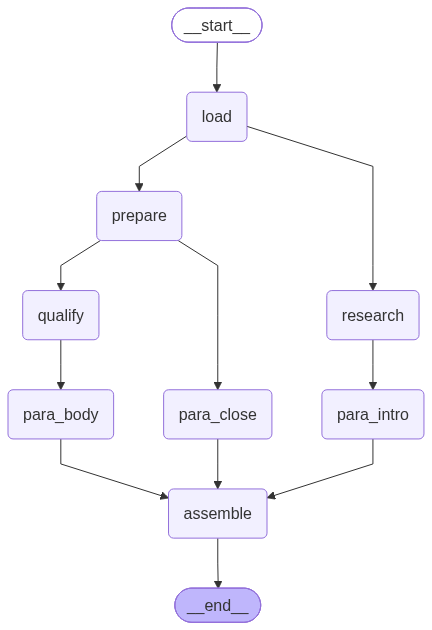

In [13]:
from IPython.display import Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as exc:                     # the PNG comes from a remote renderer
    print(f"(diagram unavailable: {exc})\n")
    print(graph.get_graph().draw_mermaid())

---
## 13. Run it

Around eight model calls, roughly three minutes.

In [14]:
def invoke_via_studio(payload: dict) -> dict:
    """Run through the `langgraph dev` server so this run shows up as a thread in Studio,
    instead of invoking `graph` in-process (which the server never sees). Falls back to the
    in-process graph when the server isn't running - keeps run_headless.py working headless."""
    from langgraph_sdk import get_sync_client
    client = get_sync_client(url="http://127.0.0.1:2024")
    try:
        thread = client.threads.create(graph_id="cover_letter")
    except Exception as exc:
        print(f"[studio] dev server not reachable ({type(exc).__name__}); running in-process")
        return graph.invoke(payload, {"recursion_limit": 30})

    print(f"[studio] thread {thread['thread_id']} - open Studio to watch it run")
    return client.runs.wait(thread["thread_id"], "cover_letter",
                             input=payload, config={"recursion_limit": 30})


result = invoke_via_studio(inputs)
print("\n" + "=" * 70)
display(Markdown(result["final_letter"]))

[studio] thread 01a0bdf9-a46c-7902-ac71-b97cf8e8308b - open Studio to watch it run



Dear Hiring Team,

Qogita's order allocation algorithm re-solves the optimal mix of sellers as prices and quantities shift minute by minute, delivering the 10–20% savings you describe — so the "business-critical ML systems" in this advert are the revenue mechanism, not a reporting layer. That is why I want to work here. The role also spans both halves of my practice: XGBoost-style ranking and demand forecasting, alongside RAG and LLM evaluation, and being the team's go-to on LLM architecture and evaluation is the seat I want.

For my EngD final project at the leading Dutch telecommunications and ICT operator, I built an evaluation framework for RAG use case optimisation, implementing a weighted sum score that normalises judge-LLM scores using output token probabilities and automating prompt engineering to maximise agreement between judge LLMs and human evaluators. That gives Qogita a defensible way to decide whether an LLM feature for catalogue enrichment or supplier matching is good enough to ship, rather than eyeballing outputs. On the same project I worked with developers on the company's new RAG API — defining user needs, communicating requirements, testing features and writing hyperparameter optimisation code — so I can specify what an LLM feature needs from the serving layer instead of handing Engineering a prototype.

Earlier, as a Postgraduate AI Research Fellow at the same operator, I fine-tuned multilingual embedding models using a multi-stage Sentence Transformers pipeline, GPT-4-generated synthetic data and semi-hard negative mining, outperforming OpenAI and Cohere baselines at significantly lower dimensionality. Supplier matching across a marketplace of 500+ suppliers in 30+ countries is that same retrieval problem, and I can argue the model-selection trade-off with measured numbers. More recently, as FEC Model Specialist at a large Dutch-headquartered international asset-finance and leasing company, I ran annual monitoring of a Customer Due Diligence model, including performance testing and reassessment of key assumptions — the discipline your business-critical ranking and pricing models will need once they are live.

Qogita's vision of building the world's leading global wholesale trading hub is exactly the kind of problem I want to work on, and I would welcome the chance to discuss how I could contribute to the intelligence layer behind your marketplace. Thank you for your consideration.

Kind regards,
Umur Yesilsoy

---
## 14. Inspect the pieces

The value of building it paragraph by paragraph is that you can look at each one, and at the
reasoning behind it, rather than at a finished letter you either like or do not.

In [15]:
print("=" * 70); print("RESEARCH NOTES AND CANDIDATE MOTIVATIONS")
print(result["research_notes"])

print("\n" + "=" * 70); print("QUALIFICATIONS -> VALUE TO THE TEAM")
for item in result["qualifications"]:
    print(f"\n  [{item['relevance']}/5] {item['qualification']}")
    print(f"       evidence : {item['evidence'][:110]}")
    print(f"       value    : {item['value_to_team'][:110]}")

print("\n" + "=" * 70); print("PARAGRAPHS AS WRITTEN")
for label, key in [("INTRO", "para_intro"), ("BODY", "para_body"), ("CLOSE", "para_close")]:
    print(f"\n--- {label} ({len(result[key].split())} words)\n{result[key]}")

if result.get("changes"):
    print("\n" + "=" * 70); print("CHANGES MADE BY ASSEMBLE")
    for change in result["changes"]:
        print("  - " + change)

RESEARCH NOTES AND CANDIDATE MOTIVATIONS
I'll research Qogita and its Data Science team.I'll call the search tool directly as instructed.## FINDINGS

**What the company does, scale, market position**
- Qogita is a two-sided B2B e-commerce wholesale marketplace connecting retailer-buyers with wholesalers/distributors/brands, largely in health and beauty [https://www.yahoo.com/news/qogita-wholesale-marketplace-retailers-raises-090050394.html]
- Founded in 2021 by Yaniv Toledano (ex-Goldman Sachs) and Danny Toledano; headquartered in London [https://www.yahoo.com/news/qogita-wholesale-marketplace-retailers-raises-090050394.html]
- CEO is Manolis Manassakis, hired externally for marketplace-scaling experience [https://www.yahoo.com/news/qogita-wholesale-marketplace-retailers-raises-090050394.html]
- Company states it connects businesses with 500+ suppliers across 30+ countries and describes itself as Europe's largest B2B wholesale platform for health, beauty and household supplies [https:/

In [16]:
print(f"SOURCES ({len(result['sources'])})")
for source in result["sources"][:12]:
    print(f"  - {source['title'][:65]}\n    {source['url']}")

SOURCES (45)
  - Qogita - Products, Competitors, Financials, Employees, Headquarte
    https://www.cbinsights.com/company/qogita
  - Qogita - Crunchbase Company Profile & Funding
    https://www.crunchbase.com/organization/qogita
  - Qogita — a wholesale marketplace for retailers — raises $86M Seri
    https://www.yahoo.com/news/qogita-wholesale-marketplace-retailers-raises-090050394.html
  - AI-powered expansion: B2B marketplace wins customers across Europ
    https://www.thinkwithgoogle.com/intl/en-emea/marketing-strategies/automation/qogita-b2b-marketplace-europe-expansion/
  - Qogita (@qogita) on X
    https://x.com/qogita?lang=en
  - Marketplace Qogita raises 80 million euros
    https://ecommercenews.eu/marketplace-qogita-raises-80-million-euros/
  - Qogita Secures $87 Million to Grow Wholesale Procurement Platform
    https://www.pymnts.com/news/investment-tracker/2023/qogita-secures-87-million-to-grow-wholesale-procurement-platform/
  - About Qogita | Europe's largest network o

---
## Worth changing

**A URL that will not fetch.** Most large job boards render postings with JavaScript or require a
login, so `job_url.txt` fails more often than it works and the loader falls back to
`job_posting.txt`. That fallback is the reliable path; treat the URL as a convenience.

**The corrective pass is single-shot by design.** If `assemble` regularly reports unresolved
problems, the fix is a better `qualify` step rather than a second corrective pass - the problems
almost always trace back to a qualification whose evidence was thin.

**`value_to_team` is the field to tune.** If the letter reads as being about the candidate rather
than about the team, that field has gone generic. Tightening its description in `QUALIFY_SYSTEM`
changes the letter more than editing any of the writing prompts.

**No human gate.** The graph runs start to finish. An `interrupt()` before `assemble` would let
you approve the paragraphs before they are stitched.

**Nothing is cached.** Each run re-analyses the CV. Keying `prepare` on a hash of the CV text
would save a call per application.

**Every rendered prompt is written to `outputs/.prompts/`** while `dump_prompts` is on - one file
per node, containing the exact system and user messages that were sent. When a paragraph comes
out wrong, read the prompt that produced it before editing the prompt template.

---
## 15. LangGraph Studio - stepping through a run node by node

This notebook stays the source of truth - prompts, nodes, the graph, all defined above.
[`graph.py`](graph.py) is a thin loader: it reads this notebook's own code cells and executes
them (the same trick [`run_headless.py`](run_headless.py) uses), then exposes the resulting
`graph`. [`langgraph.json`](langgraph.json) points Studio at `./graph.py:graph`.

```bash
langgraph dev
```

This prints a Studio URL (`https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024`) -
open it, logged into your LangSmith account. From there you can:

- invoke the graph with `{}` as input - the `load` node added in section 12 reads `inputs/` from
  disk itself, so there is nothing to paste in
- watch each node run, edit state, jump into a node, resume from any node
- see the same run land in LangSmith as a trace, once `LANGSMITH_TRACING=true` and
  `LANGSMITH_API_KEY` are set in `.env` (added in Setup above)

Edit prompts and nodes here, as usual, and save. `langgraph dev` hot-reloads `graph.py` on file
change, which re-reads this notebook from disk - so a saved edit shows up in Studio without
restarting the server. (Jupyter's autosave can lag a manual save by a few seconds; save explicitly
with Cmd/Ctrl+S if a change isn't picked up.)